In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split



In [15]:
df = pd.read_csv('Station1-Simulated-cleaned-merged-data.csv', sep=",", parse_dates=["Date"], index_col="Date")
tair_series = df['Tair']

train_size = int(len(tair_series) * 0.8) ## Creating split between training on first 58 months
train_data, test_data = tair_series[:train_size], tair_series[train_size:] ## and testing on last 14

In [16]:
arima_order = (1, 0, 0) ## Testing originally only on simple AR model
model = ARIMA(train_data, order=arima_order)
model_fit = model.fit()

predictions = model_fit.forecast(steps=len(test_data))


/Users/alihajibeigi/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alihajibeigi/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alihajibeigi/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alihajibeigi/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer

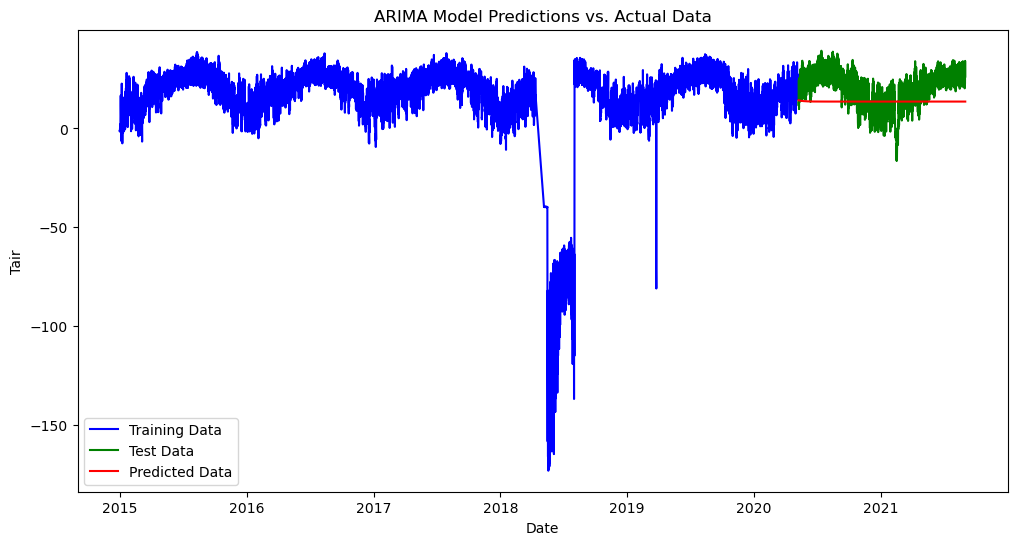

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(tair_series.index[:train_size], train_data, label='Training Data', color='blue')
plt.plot(tair_series.index[train_size:], test_data, label='Test Data', color='green')
plt.plot(tair_series.index[train_size:], predictions, label='Predicted Data', color='red')

plt.xlabel('Date')
plt.ylabel('Tair')
plt.title('ARIMA Model Predictions vs. Actual Data')
plt.legend()
plt.show()

/Users/alihajibeigi/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alihajibeigi/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alihajibeigi/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/alihajibeigi/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer

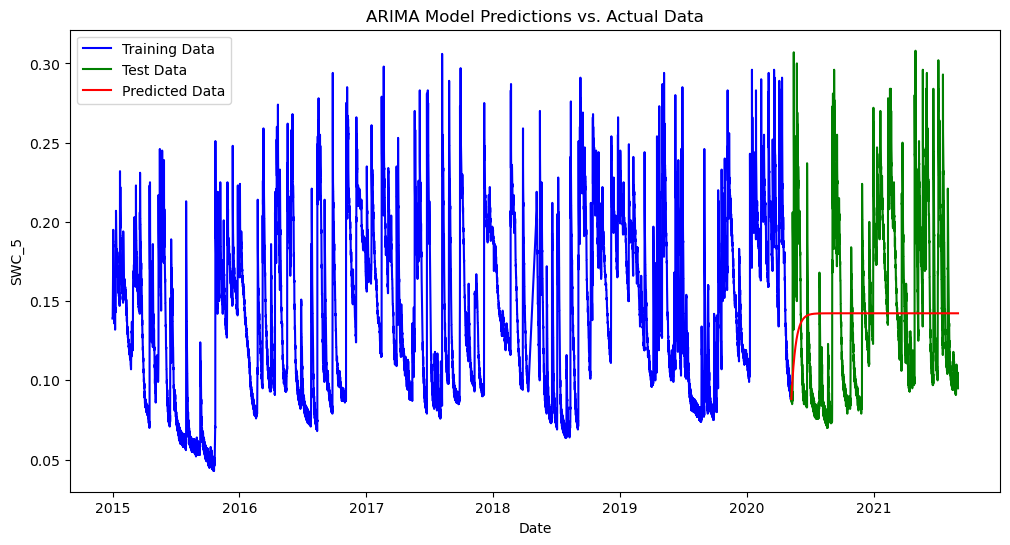

In [20]:
swc_series = df['SWC_5']

train_data2, test_data2 = swc_series[:train_size], swc_series[train_size:]

arima_order2 = (1, 0, 0)
model2 = ARIMA(train_data2, order=arima_order2)
model_fit2 = model2.fit()

predictions2 = model_fit2.forecast(steps=len(test_data2))

plt.figure(figsize=(12, 6))
plt.plot(swc_series.index[:train_size2], train_data2, label='Training Data', color='blue')
plt.plot(swc_series.index[train_size2:], test_data2, label='Test Data', color='green')
plt.plot(swc_series.index[train_size2:], predictions2, label='Predicted Data', color='red')

plt.xlabel('Date')
plt.ylabel('SWC_5')
plt.title('ARIMA Model Predictions vs. Actual Data')
plt.legend()
plt.show()